# 07 — Genotype-expression integration

This notebook integrates genomic alterations with RNA-seq expression data.

The goal is to test whether selected copy-number or mutation events have observable transcriptomic consequences, and to connect genomic alteration patterns with subtype biology.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, fisher_exact

pd.set_option("display.max_columns", 100)
sns.set_context("notebook")

In [2]:
PROJECT_ROOT = Path("..").resolve()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

driver_path = PROCESSED_DIR / "multiomics_driver_alteration_table.tsv"
expression_path = PROCESSED_DIR / "expression_rsem_samples_by_gene.tsv"

print("Driver table exists:", driver_path.exists())
print("Expression table exists:", expression_path.exists())

Driver table exists: True
Expression table exists: True


In [3]:
driver_table = pd.read_csv(driver_path, sep="\t")
expression = pd.read_csv(expression_path, sep="\t")

print("driver_table:", driver_table.shape)
print("expression:", expression.shape)

display(driver_table.head())
display(expression.head())

driver_table: (1082, 55)
expression: (1082, 20514)


,SAMPLE_ID_15,PATIENT_ID_12,SUBTYPE,TP53_mut,PIK3CA_mut,GATA3_mut,CDH1_mut,MAP3K1_mut,BRCA1_mut,BRCA2_mut,ERBB2_mut,MYC_mut,CCND1_mut,PTEN_mut,AKT1_mut,RB1_mut,TP53_amp,PIK3CA_amp,GATA3_amp,CDH1_amp,MAP3K1_amp,BRCA1_amp,BRCA2_amp,ERBB2_amp,MYC_amp,CCND1_amp,PTEN_amp,AKT1_amp,RB1_amp,TP53_del,PIK3CA_del,GATA3_del,CDH1_del,MAP3K1_del,BRCA1_del,BRCA2_del,ERBB2_del,MYC_del,CCND1_del,PTEN_del,AKT1_del,RB1_del,TP53_any_alt,PIK3CA_any_alt,GATA3_any_alt,CDH1_any_alt,MAP3K1_any_alt,BRCA1_any_alt,BRCA2_any_alt,ERBB2_any_alt,MYC_any_alt,CCND1_any_alt,PTEN_any_alt,AKT1_any_alt,RB1_any_alt
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,BRCA_LumA,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
1,TCGA-3C-AALI-01,TCGA-3C-AALI,BRCA_Her2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,BRCA_LumB,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0
3,TCGA-3C-AALK-01,TCGA-3C-AALK,BRCA_LumA,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,BRCA_LumA,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0


,SAMPLE_ID_ORIGINAL,SAMPLE_ID_15,PATIENT_ID_12,A1BG,A1CF,A2BP1,A2LD1,A2M,A2M-AS1,A2ML1,A4GALT,A4GNT,AAA1,AAAS,AACS,AACSL,AADAC,AADACL2,AADACL3,AADACL4,AADACP1,AADAT,AAGAB,AAK1,AAMP,AANAT,AARS,AARS2,AARSD1,AASDH,AASDHPPT,AASS,AATBC,AATF,AATK,ABAT,ABCA1,ABCA10,ABCA11P,ABCA12,ABCA13,ABCA17P,ABCA2,ABCA3,ABCA4,ABCA5,ABCA6,ABCA7,ABCA8,ABCA9,...,ZNRF2,ZNRF2P1,ZNRF3,ZNRF4,ZP1,ZP2,ZP3,ZP4,ZPBP,ZPBP2,ZPLD1,ZRANB1,ZRANB2,ZRANB3,ZRSR2,ZSCAN1,ZSCAN10,ZSCAN12,ZSCAN12P1,ZSCAN16,ZSCAN18,ZSCAN2,ZSCAN20,ZSCAN21,ZSCAN22,ZSCAN23,ZSCAN29,ZSCAN4,ZSCAN5A,ZSCAN5B,ZSWIM1,ZSWIM2,ZSWIM3,ZSWIM4,ZSWIM5,ZSWIM6,ZSWIM7,ZUFSP,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,TCGA-3C-AAAU,197.090,0.0000,0.0000,102.9630,5798.37,32.2187,1.3786,68.2424,8.6165,0.3447,649.337,1087.400,1.3786,0.0000,0.0,0.0000,0.0,0.0000,5.5145,1300.40,517.333,2053.13,0.3447,4409.56,689.897,466.668,277.450,808.914,45.8396,111.6690,1518.91,619.5930,620.731,288.462,16.2334,79.1509,321.2220,0.0000,17.9223,4507.450,5470.770,3.7912,795.093,23.0921,596.9490,58.5920,37.5678,...,414.969,76.1696,741.706,0.0,3.7912,0.0000,411.791,0.0000,1.034,0.3447,53.7668,879.225,2504.080,72.0337,421.862,0.3447,2.7573,141.6550,128.1790,225.062,132.349,582.473,158.8880,253.510,300.887,38.2571,960.220,0.3447,32.3979,1.0340,431.513,0.3447,180.2570,489.416,454.9500,621.764,194.108,89.956,430.824,415.824,931.957,129.5920,1007.780,1658.500,258.4940,1208.370,3507.25,1894.930,1180.460,1.7233
1,TCGA-3C-AALI-01,TCGA-3C-AALI-01,TCGA-3C-AALI,237.384,0.0000,0.0000,70.8646,7571.98,29.9782,4.3502,157.6940,0.5438,0.0000,887.983,836.324,35.3453,1.0875,0.0,0.0000,0.0,0.0000,24.4698,3541.05,848.287,2979.88,2.1751,4570.96,472.501,418.706,184.339,678.630,71.7781,13.5943,7649.27,107.6670,240.348,421.930,17.9445,96.0903,678.6300,1.6313,70.6906,2330.070,2656.880,45.1332,388.798,25.0136,763.4580,20.1196,46.2208,...,841.218,39.6955,373.573,0.0,30.4513,4.3502,439.222,0.5438,0.000,2.1751,3.2626,566.068,627.656,62.5340,349.647,18.4883,0.0000,91.8978,58.2164,174.551,1549.760,236.542,27.7325,698.521,197.390,7.0691,588.363,0.0000,127.7870,4.3502,507.341,0.0000,139.2060,475.802,113.6490,242.523,217.134,105.492,340.402,1161.330,965.198,59.8151,448.613,1343.120,198.4770,603.589,5504.62,1318.650,406.743,926.5910
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,TCGA-3C-AALJ,423.237,0.9066,0.0000,161.2600,8840.40,17.2620,0.0000,573.8890,0.0000,0.0000,723.481,1533.090,2.7199,0.9066,0.0,1.8132,0.0,1.8132,53.4905,1360.83,568.450,2291.93,1.8132,2556.66,439.710,390.752,190.390,779.692,76.1559,20.8522,2097.91,145.0590,375.340,689.882,27.1985,156.0200,0.0000,0.9066,12.6927,3208.520,1514.050,1.8132,559.384,81.5956,383.5000,52.5839,54.3971,...,266.546,38.9846,257.480,0.0,2.7199,0.0000,334.506,0.0000,0.000,0.0000,117.8600,1125.110,1951.210,35.3581,470.535,112.4210,0.0000,99.7280,38.2684,110.607,2225.750,268.359,52.5839,282.865,138.713,46.2375,514.053,0.0000,62.5567,0.0000,352.675,0.0000,81.5956,485.947,180.4170,506.800,164.234,235.721,304.624,305.422,2531.280,35.3581,533.998,768.812,331.8220,532.185,5458.75,942.883,509.519,35.3581
3,TCGA-3C-AALK-01,TCGA-3C-AALK-01,TCGA-3C-AALK,191.018,0.0000,0.0000,62.5072,10960.20,17.8527,1.6549,506.4130,0.0000,0.0000,776.996,858.088,0.0000,2.8962,0.0,0.0000,0.0,1.2412,57.0956,1683.49,727.762,2762.52,0.4137,2122.88,431.936,493.587,196.525,665.288,183.2850,38.8912,1915.18,119.9840,1721.560,749.264,23.5830,137.3230,1430.7000,2.4824,9.1022,1375.260,968.556,73.2313,412.081,78.1961,465.8670,213.4880,70.3351,...,632.602,50.0621,330.161,0.0,1.2412,1.6549,127.017,0.4137,0.000,0.0000,9.1022,780.306,1195.830,61.2329,364.501,6.2060,0.8275,211.8330,33.4506,163.012,1276.380,304.923,36.8225,300.625,122.466,26.4791,409.185,0.4137,57.5093,0.8275,286.305,0.0000,67.0252,626.396,107.5710,340.505,196.136,148.531,314.026,394.506,668.597,55.0269,437.733,863.881,175.4240,607.365,5691.35,781.134,700.869,66.6115
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK-01,TCGA-4H-AAAK,268.881,0.4255,3.8298,154.3700,9585.44,31.5787

In [4]:
id_cols = ["SAMPLE_ID_15", "PATIENT_ID_12"]

df = driver_table.merge(
    expression,
    on=id_cols,
    how="inner"
)

print("Integrated table:", df.shape)
display(df.head())

Integrated table: (1082, 20567)


,SAMPLE_ID_15,PATIENT_ID_12,SUBTYPE,TP53_mut,PIK3CA_mut,GATA3_mut,CDH1_mut,MAP3K1_mut,BRCA1_mut,BRCA2_mut,ERBB2_mut,MYC_mut,CCND1_mut,PTEN_mut,AKT1_mut,RB1_mut,TP53_amp,PIK3CA_amp,GATA3_amp,CDH1_amp,MAP3K1_amp,BRCA1_amp,BRCA2_amp,ERBB2_amp,MYC_amp,CCND1_amp,PTEN_amp,AKT1_amp,RB1_amp,TP53_del,PIK3CA_del,GATA3_del,CDH1_del,MAP3K1_del,BRCA1_del,BRCA2_del,ERBB2_del,MYC_del,CCND1_del,PTEN_del,AKT1_del,RB1_del,TP53_any_alt,PIK3CA_any_alt,GATA3_any_alt,CDH1_any_alt,MAP3K1_any_alt,BRCA1_any_alt,BRCA2_any_alt,ERBB2_any_alt,...,ZNRF2,ZNRF2P1,ZNRF3,ZNRF4,ZP1,ZP2,ZP3,ZP4,ZPBP,ZPBP2,ZPLD1,ZRANB1,ZRANB2,ZRANB3,ZRSR2,ZSCAN1,ZSCAN10,ZSCAN12,ZSCAN12P1,ZSCAN16,ZSCAN18,ZSCAN2,ZSCAN20,ZSCAN21,ZSCAN22,ZSCAN23,ZSCAN29,ZSCAN4,ZSCAN5A,ZSCAN5B,ZSWIM1,ZSWIM2,ZSWIM3,ZSWIM4,ZSWIM5,ZSWIM6,ZSWIM7,ZUFSP,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,BRCA_LumA,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,...,414.969,76.1696,741.706,0.0,3.7912,0.0000,411.791,0.0000,1.034,0.3447,53.7668,879.225,2504.080,72.0337,421.862,0.3447,2.7573,141.6550,128.1790,225.062,132.349,582.473,158.8880,253.510,300.887,38.2571,960.220,0.3447,32.3979,1.0340,431.513,0.3447,180.2570,489.416,454.9500,621.764,194.108,89.956,430.824,415.824,931.957,129.5920,1007.780,1658.500,258.4940,1208.370,3507.25,1894.930,1180.460,1.7233
1,TCGA-3C-AALI-01,TCGA-3C-AALI,BRCA_Her2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,841.218,39.6955,373.573,0.0,30.4513,4.3502,439.222,0.5438,0.000,2.1751,3.2626,566.068,627.656,62.5340,349.647,18.4883,0.0000,91.8978,58.2164,174.551,1549.760,236.542,27.7325,698.521,197.390,7.0691,588.363,0.0000,127.7870,4.3502,507.341,0.0000,139.2060,475.802,113.6490,242.523,217.134,105.492,340.402,1161.330,965.198,59.8151,448.613,1343.120,198.4770,603.589,5504.62,1318.650,406.743,926.5910
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,BRCA_LumB,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,...,266.546,38.9846,257.480,0.0,2.7199,0.0000,334.506,0.0000,0.000,0.0000,117.8600,1125.110,1951.210,35.3581,470.535,112.4210,0.0000,99.7280,38.2684,110.607,2225.750,268.359,52.5839,282.865,138.713,46.2375,514.053,0.0000,62.5567,0.0000,352.675,0.0000,81.5956,485.947,180.4170,506.800,164.234,235.721,304.624,305.422,2531.280,35.3581,533.998,768.812,331.8220,532.185,5458.75,942.883,509.519,35.3581
3,TCGA-3C-AALK-01,TCGA-3C-AALK,BRCA_LumA,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,...,632.602,50.0621,330.161,0.0,1.2412,1.6549,127.017,0.4137,0.000,0.0000,9.1022,780.306,1195.830,61.2329,364.501,6.2060,0.8275,211.8330,33.4506,163.012,1276.380,304.923,36.8225,300.625,122.466,26.4791,409.185,0.4137,57.5093,0.8275,286.305,0.0000,67.0252,626.396,107.5710,340.505,196.136,148.531,314.026,394.506,668.597,55.0269,437.733,863.881,175.4240,607.365,5691.35,781.134,700.869,66.6115
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,BRCA_LumA,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,...,572.340,40.0000,354.894,0.0,0.0000,0.0000,327.979,0.4255,0.000,0.0000,9.7872,1118.720,1423.410,58.7234,305.106,39.1489,0.0000,107.2340,31.6851,136.149,1567.230,331.915,73.1915,314.923,160.000,9.7872,297.447,0.4255,62.9787,1.7021,278.298,0.0000,79.1489,912.340,61.2766,305.106,182.915,143.404,297.872,405.711,674.468,48.9362,424.255,1049.790,14.0426,775.745,4041.70,831.915,881.702,187.2340


In [5]:
genes_to_check = [
    "ERBB2",
    "CCND1",
    "MYC",
    "PTEN",
    "RB1",
    "TP53",
    "PIK3CA",
    "MKI67",
    "ESR1",
    "PGR",
    "FOXA1",
    "GATA3",
]

available_expression_genes = [
    gene for gene in genes_to_check
    if gene in df.columns
]

missing_expression_genes = [
    gene for gene in genes_to_check
    if gene not in df.columns
]

print("Available expression genes:", available_expression_genes)
print("Missing expression genes:", missing_expression_genes)

for gene in available_expression_genes:
    df[f"log2_{gene}"] = np.log2(pd.to_numeric(df[gene], errors="coerce") + 1)

display(
    df[
        ["SAMPLE_ID_15", "PATIENT_ID_12", "SUBTYPE"]
        + [f"log2_{gene}" for gene in available_expression_genes]
    ].head()
)

Available expression genes: ['ERBB2', 'CCND1', 'MYC', 'PTEN', 'RB1', 'TP53', 'PIK3CA', 'MKI67', 'ESR1', 'PGR', 'FOXA1', 'GATA3']
Missing expression genes: []


/var/folders/4v/slg8ycv93dbf9f_y4_ns4g2r0000gn/T/ipykernel_16870/2019881797.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"log2_{gene}"] = np.log2(pd.to_numeric(df[gene], errors="coerce") + 1)


,SAMPLE_ID_15,PATIENT_ID_12,SUBTYPE,log2_ERBB2,log2_CCND1,log2_MYC,log2_PTEN,log2_RB1,log2_TP53,log2_PIK3CA,log2_MKI67,log2_ESR1,log2_PGR,log2_FOXA1,log2_GATA3
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,BRCA_LumA,12.796528,15.553980,11.119421,10.752657,8.957999,10.437263,8.930746,11.335318,11.756123,11.151188,12.411874,13.807606
1,TCGA-3C-AALI-01,TCGA-3C-AALI,BRCA_Her2,17.570345,11.875715,7.473511,10.113195,9.564891,8.698205,8.335006,11.158913,6.119263,4.817045,12.562834,12.860843
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,BRCA_LumB,13.434589,13.214633,10.247773,10.531079,9.654774,10.333390,7.766078,9.892131,12.869463,8.891282,12.174030,13.323885
3,TCGA-3C-AALK-01,TCGA-3C-AALK,BRCA_LumA,15.136663,14.305257,10.458284,10.875074,9.967226,10.470954,8.353253,10.155362,11.279790,11.127646,12.844135,13.097158
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,BRCA_LumA,13.579033,13.197708,12.014875,10.765344,9.907753,10.536500,8.683742,10.237664,12.430270,12.111850,12.731440,13.780283


In [6]:
def plot_expression_by_event(
    df,
    event_col,
    expression_col,
    positive_label="Altered",
    negative_label="Not altered",
    title=None,
    filename=None,
):
    if event_col not in df.columns:
        print(f"{event_col} not found.")
        return None
    
    if expression_col not in df.columns:
        print(f"{expression_col} not found.")
        return None
    
    plot_df = df[[event_col, expression_col, "SUBTYPE"]].dropna().copy()
    plot_df = plot_df[plot_df[event_col].isin([0, 1])].copy()
    
    if plot_df[event_col].nunique() < 2:
        print(f"{event_col}: only one group present.")
        return None
    
    plot_df["event_status"] = plot_df[event_col].map({
        0: negative_label,
        1: positive_label,
    })
    
    x0 = plot_df.loc[plot_df[event_col] == 0, expression_col].dropna()
    x1 = plot_df.loc[plot_df[event_col] == 1, expression_col].dropna()
    
    stat, p_value = mannwhitneyu(x1, x0, alternative="two-sided")
    
    summary = {
        "event": event_col,
        "expression": expression_col,
        "n_not_altered": len(x0),
        "n_altered": len(x1),
        "median_not_altered": x0.median(),
        "median_altered": x1.median(),
        "median_difference_altered_minus_not": x1.median() - x0.median(),
        "p_value": p_value,
    }
    
    display(pd.DataFrame([summary]))
    
    plt.figure(figsize=(6, 4))
    sns.boxplot(
        data=plot_df,
        x="event_status",
        y=expression_col,
    )
    sns.stripplot(
        data=plot_df,
        x="event_status",
        y=expression_col,
        color="black",
        alpha=0.25,
        size=2,
    )
    
    if title is None:
        title = f"{expression_col} by {event_col}"
    
    plt.title(title)
    plt.xlabel("")
    plt.ylabel(expression_col.replace("log2_", "log2 expression: "))
    plt.tight_layout()
    
    if filename is not None:
        plt.savefig(FIGURES_DIR / filename, dpi=300)
    
    plt.show()
    
    return summary

,event,expression,n_not_altered,n_altered,median_not_altered,median_altered,median_difference_altered_minus_not,p_value
0,ERBB2_amp,log2_ERBB2,866,115,12.629169,16.52873,3.899562,2.039303e-62


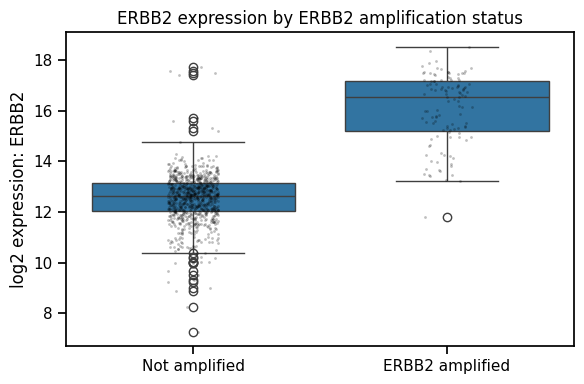

In [7]:
summaries = []

summary = plot_expression_by_event(
    df=df,
    event_col="ERBB2_amp",
    expression_col="log2_ERBB2",
    positive_label="ERBB2 amplified",
    negative_label="Not amplified",
    title="ERBB2 expression by ERBB2 amplification status",
    filename="ERBB2_expression_by_ERBB2_amplification.png",
)

if summary is not None:
    summaries.append(summary)

,event,expression,n_not_altered,n_altered,median_not_altered,median_altered,median_difference_altered_minus_not,p_value
0,CCND1_amp,log2_CCND1,829,152,12.707771,14.580025,1.872254,5.483880e-52


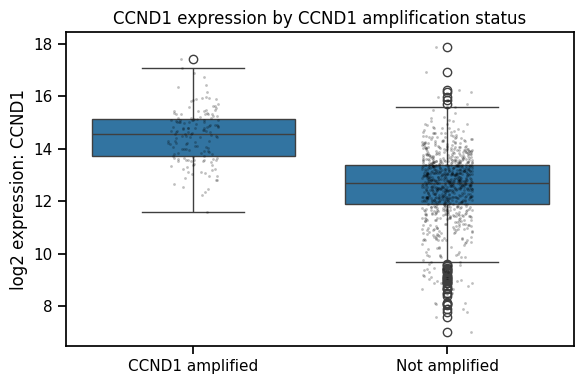

In [8]:
summary = plot_expression_by_event(
    df=df,
    event_col="CCND1_amp",
    expression_col="log2_CCND1",
    positive_label="CCND1 amplified",
    negative_label="Not amplified",
    title="CCND1 expression by CCND1 amplification status",
    filename="CCND1_expression_by_CCND1_amplification.png",
)

if summary is not None:
    summaries.append(summary)

,event,expression,n_not_altered,n_altered,median_not_altered,median_altered,median_difference_altered_minus_not,p_value
0,MYC_amp,log2_MYC,828,153,10.601752,11.178466,0.576713,1.097109e-08


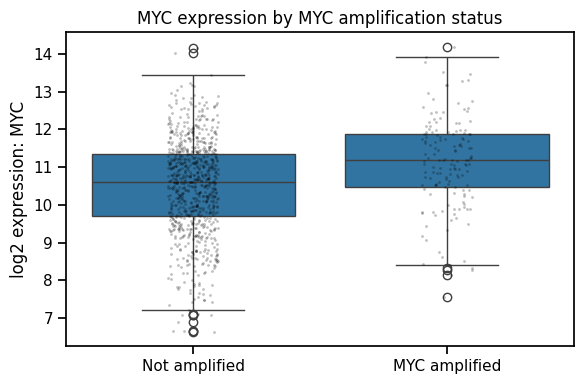

In [9]:
summary = plot_expression_by_event(
    df=df,
    event_col="MYC_amp",
    expression_col="log2_MYC",
    positive_label="MYC amplified",
    negative_label="Not amplified",
    title="MYC expression by MYC amplification status",
    filename="MYC_expression_by_MYC_amplification.png",
)

if summary is not None:
    summaries.append(summary)

,event,expression,n_not_altered,n_altered,median_not_altered,median_altered,median_difference_altered_minus_not,p_value
0,PTEN_del,log2_PTEN,931,50,10.972075,9.450117,-1.521958,2.352051e-21


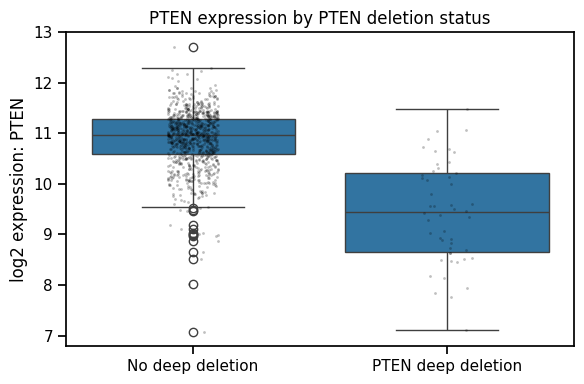

In [10]:
summary = plot_expression_by_event(
    df=df,
    event_col="PTEN_del",
    expression_col="log2_PTEN",
    positive_label="PTEN deep deletion",
    negative_label="No deep deletion",
    title="PTEN expression by PTEN deletion status",
    filename="PTEN_expression_by_PTEN_deletion.png",
)

if summary is not None:
    summaries.append(summary)

In [11]:
event_expression_summary = pd.DataFrame(summaries)

display(event_expression_summary)

event_expression_summary.to_csv(
    TABLES_DIR / "genomic_event_expression_association_summary.csv",
    index=False
)

,event,expression,n_not_altered,n_altered,median_not_altered,median_altered,median_difference_altered_minus_not,p_value
0,ERBB2_amp,log2_ERBB2,866,115,12.629169,16.528730,3.899562,2.039303e-62
1,CCND1_amp,log2_CCND1,829,152,12.707771,14.580025,1.872254,5.483880e-52
2,MYC_amp,log2_MYC,828,153,10.601752,11.178466,0.576713,1.097109e-08
3,PTEN_del,log2_PTEN,931,50,10.972075,9.450117,-1.521958,2.352051e-21


,SUBTYPE,ERBB2_amp
1,BRCA_Her2,0.705128
3,BRCA_LumB,0.121827
4,BRCA_Normal,0.083333
2,BRCA_LumA,0.062124
0,BRCA_Basal,0.011696


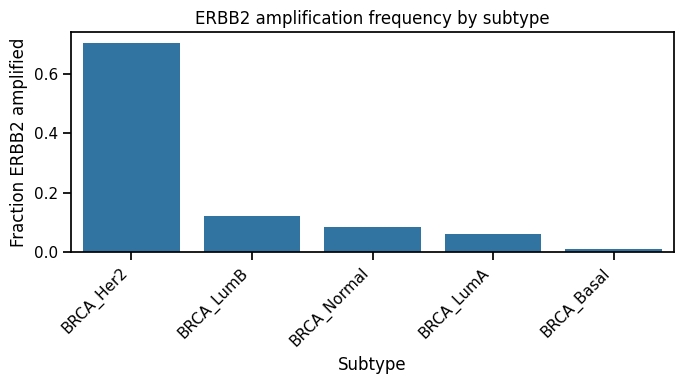

In [12]:
if "ERBB2_amp" in df.columns:
    erbb2_amp_by_subtype = (
        df.groupby("SUBTYPE")["ERBB2_amp"]
        .mean()
        .reset_index()
        .sort_values("ERBB2_amp", ascending=False)
    )
    
    display(erbb2_amp_by_subtype)
    
    erbb2_amp_by_subtype.to_csv(
        TABLES_DIR / "ERBB2_amplification_frequency_by_subtype.csv",
        index=False
    )
    
    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=erbb2_amp_by_subtype,
        x="SUBTYPE",
        y="ERBB2_amp",
    )
    plt.title("ERBB2 amplification frequency by subtype")
    plt.xlabel("Subtype")
    plt.ylabel("Fraction ERBB2 amplified")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "ERBB2_amplification_frequency_by_subtype.png", dpi=300)
    plt.show()

,SUBTYPE,TP53_mut
0,BRCA_Basal,0.894737
1,BRCA_Her2,0.705128
3,BRCA_LumB,0.360406
4,BRCA_Normal,0.305556
2,BRCA_LumA,0.106212


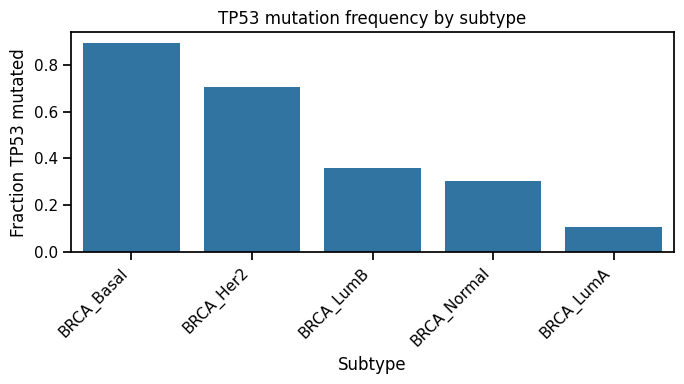

In [13]:
if "TP53_mut" in df.columns:
    tp53_mut_by_subtype = (
        df.groupby("SUBTYPE")["TP53_mut"]
        .mean()
        .reset_index()
        .sort_values("TP53_mut", ascending=False)
    )
    
    display(tp53_mut_by_subtype)
    
    tp53_mut_by_subtype.to_csv(
        TABLES_DIR / "TP53_mutation_frequency_by_subtype.csv",
        index=False
    )
    
    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=tp53_mut_by_subtype,
        x="SUBTYPE",
        y="TP53_mut",
    )
    plt.title("TP53 mutation frequency by subtype")
    plt.xlabel("Subtype")
    plt.ylabel("Fraction TP53 mutated")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "TP53_mutation_frequency_by_subtype.png", dpi=300)
    plt.show()

,event,expression,n_not_altered,n_altered,median_not_altered,median_altered,median_difference_altered_minus_not,p_value
0,TP53_mut,log2_MKI67,638,343,10.387312,11.54607,1.158758,3.455499e-49


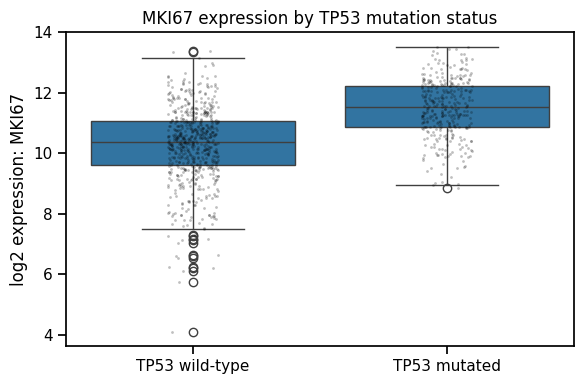

,event,expression,n_not_altered,n_altered,median_not_altered,median_altered,median_difference_altered_minus_not,p_value
0,TP53_mut,log2_MKI67,638,343,10.387312,11.54607,1.158758,3.455499e-49


In [14]:
summary = plot_expression_by_event(
    df=df,
    event_col="TP53_mut",
    expression_col="log2_MKI67",
    positive_label="TP53 mutated",
    negative_label="TP53 wild-type",
    title="MKI67 expression by TP53 mutation status",
    filename="MKI67_expression_by_TP53_mutation.png",
)

if summary is not None:
    display(pd.DataFrame([summary]))

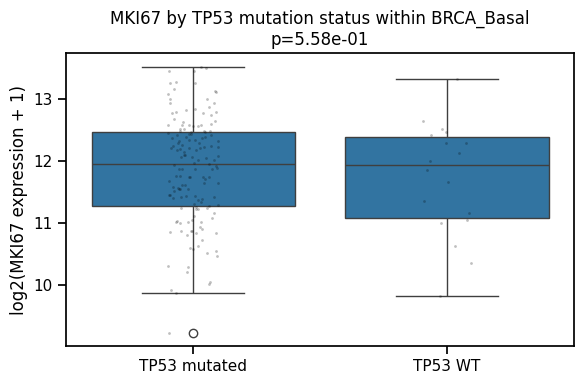

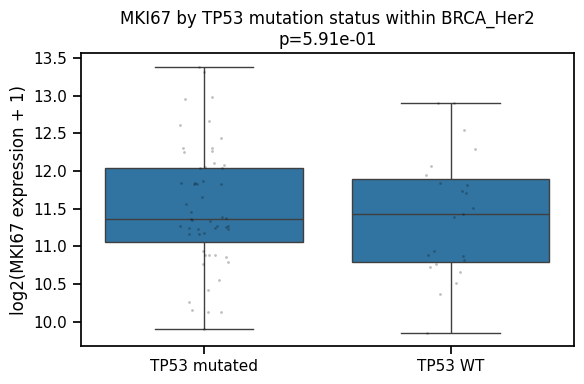

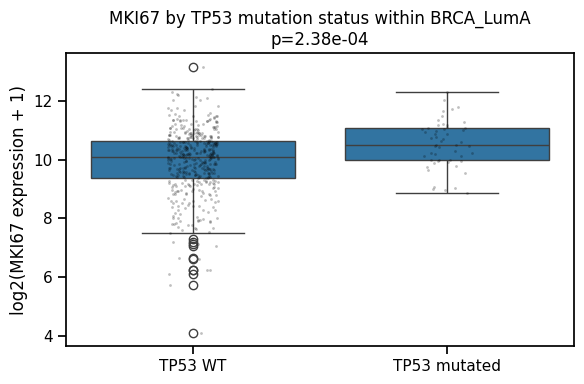

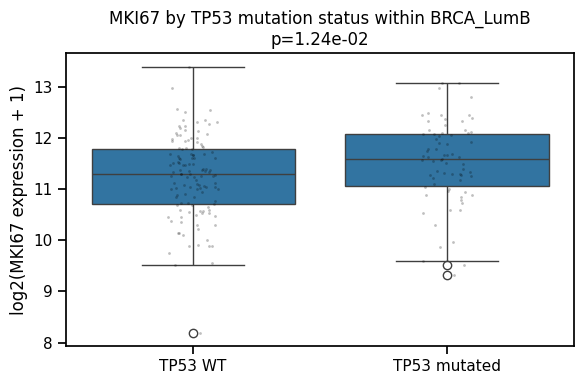

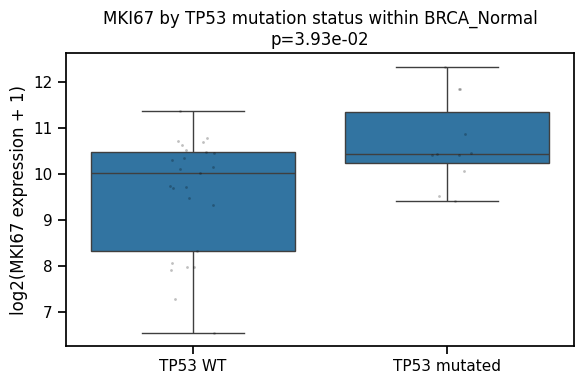

In [15]:
if "TP53_mut" in df.columns and "log2_MKI67" in df.columns:
    for subtype in ["BRCA_Basal", "BRCA_Her2", "BRCA_LumA", "BRCA_LumB", "BRCA_Normal"]:
        subtype_df = df[df["SUBTYPE"] == subtype].copy()
        
        if subtype_df["TP53_mut"].nunique() < 2:
            print(f"{subtype}: only one TP53 status group present, skipping.")
            continue
        
        n_mut = subtype_df["TP53_mut"].sum()
        n_wt = (subtype_df["TP53_mut"] == 0).sum()
        
        if n_mut < 5 or n_wt < 5:
            print(f"{subtype}: too few samples in one group, skipping. WT={n_wt}, MUT={n_mut}")
            continue
        
        plt.figure(figsize=(6, 4))
        subtype_df["TP53_status"] = subtype_df["TP53_mut"].map({
            0: "TP53 WT",
            1: "TP53 mutated",
        })
        
        sns.boxplot(
            data=subtype_df,
            x="TP53_status",
            y="log2_MKI67",
        )
        sns.stripplot(
            data=subtype_df,
            x="TP53_status",
            y="log2_MKI67",
            color="black",
            alpha=0.25,
            size=2,
        )
        
        wt = subtype_df.loc[subtype_df["TP53_mut"] == 0, "log2_MKI67"].dropna()
        mut = subtype_df.loc[subtype_df["TP53_mut"] == 1, "log2_MKI67"].dropna()
        stat, p_value = mannwhitneyu(mut, wt, alternative="two-sided")
        
        plt.title(f"MKI67 by TP53 mutation status within {subtype}\np={p_value:.2e}")
        plt.xlabel("")
        plt.ylabel("log2(MKI67 expression + 1)")
        plt.tight_layout()
        
        safe_subtype = subtype.replace("BRCA_", "")
        plt.savefig(
            FIGURES_DIR / f"MKI67_by_TP53_mutation_within_{safe_subtype}.png",
            dpi=300,
        )
        plt.show()

,SUBTYPE,PIK3CA_mut
2,BRCA_LumA,0.474950
1,BRCA_Her2,0.333333
3,BRCA_LumB,0.299492
4,BRCA_Normal,0.222222
0,BRCA_Basal,0.070175


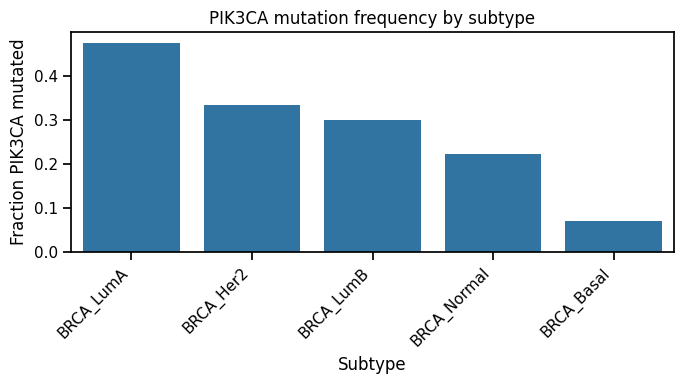

In [16]:
if "PIK3CA_mut" in df.columns:
    pik3ca_mut_by_subtype = (
        df.groupby("SUBTYPE")["PIK3CA_mut"]
        .mean()
        .reset_index()
        .sort_values("PIK3CA_mut", ascending=False)
    )
    
    display(pik3ca_mut_by_subtype)
    
    pik3ca_mut_by_subtype.to_csv(
        TABLES_DIR / "PIK3CA_mutation_frequency_by_subtype.csv",
        index=False
    )
    
    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=pik3ca_mut_by_subtype,
        x="SUBTYPE",
        y="PIK3CA_mut",
    )
    plt.title("PIK3CA mutation frequency by subtype")
    plt.xlabel("Subtype")
    plt.ylabel("Fraction PIK3CA mutated")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "PIK3CA_mutation_frequency_by_subtype.png", dpi=300)
    plt.show()

,event,expression,n_not_altered,n_altered,median_not_altered,median_altered,median_difference_altered_minus_not,p_value
0,PIK3CA_mut,log2_ESR1,639,342,12.593144,13.078645,0.485501,5.332720e-07


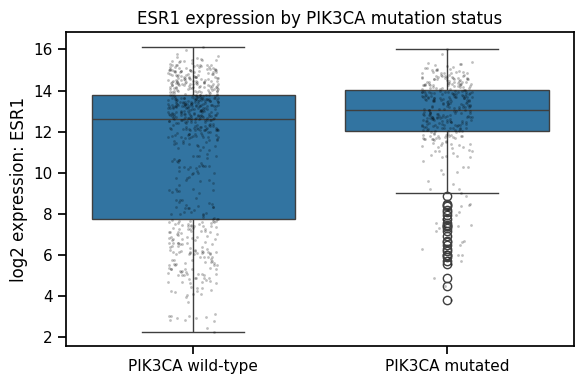

,event,expression,n_not_altered,n_altered,median_not_altered,median_altered,median_difference_altered_minus_not,p_value
0,PIK3CA_mut,log2_ESR1,639,342,12.593144,13.078645,0.485501,5.332720e-07


In [17]:
summary = plot_expression_by_event(
    df=df,
    event_col="PIK3CA_mut",
    expression_col="log2_ESR1",
    positive_label="PIK3CA mutated",
    negative_label="PIK3CA wild-type",
    title="ESR1 expression by PIK3CA mutation status",
    filename="ESR1_expression_by_PIK3CA_mutation.png",
)

if summary is not None:
    display(pd.DataFrame([summary]))

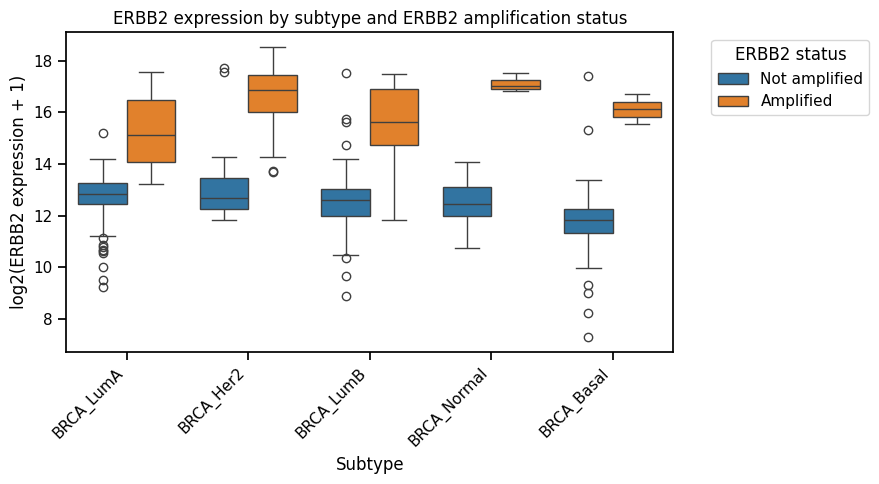

In [18]:
if {"ERBB2_amp", "log2_ERBB2", "SUBTYPE"}.issubset(df.columns):
    plot_df = df.copy()
    plot_df["ERBB2_amp_status"] = plot_df["ERBB2_amp"].map({
        0: "Not amplified",
        1: "Amplified",
    })
    
    plt.figure(figsize=(9, 5))
    sns.boxplot(
        data=plot_df,
        x="SUBTYPE",
        y="log2_ERBB2",
        hue="ERBB2_amp_status",
    )
    plt.title("ERBB2 expression by subtype and ERBB2 amplification status")
    plt.xlabel("Subtype")
    plt.ylabel("log2(ERBB2 expression + 1)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="ERBB2 status", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / "ERBB2_expression_by_subtype_and_amplification.png",
        dpi=300,
    )
    plt.show()

## Interpretation

This notebook connects genomic alteration events with transcriptomic readouts.

The strongest expected positive control is ERBB2 amplification. If ERBB2-amplified samples show higher ERBB2 expression, this supports the integration of copy-number and RNA-seq data and links a genomic driver event to a transcriptomic phenotype.

Other alteration-expression relationships should be interpreted more cautiously. For example, TP53 mutation may be associated with higher MKI67 expression, but this relationship can be confounded by subtype because TP53 mutations are highly enriched in Basal-like and HER2-enriched tumours. Therefore, subtype-stratified analyses are useful to avoid overinterpreting global associations.

Overall, this analysis demonstrates multi-omic reasoning: genomic alterations are interpreted together with expression data and molecular subtype context.

## Subtype-adjusted alteration-expression associations

In [22]:
import statsmodels.formula.api as smf

association_tests = [
    ("log2_ERBB2", "ERBB2_amp"),
    ("log2_CCND1", "CCND1_amp"),
    ("log2_MYC", "MYC_amp"),
    ("log2_PTEN", "PTEN_del"),
    ("log2_MKI67", "TP53_mut"),
    ("log2_ESR1", "PIK3CA_mut"),
]

adjusted_results = []

for expression_col, event_col in association_tests:
    if expression_col not in df.columns or event_col not in df.columns:
        continue
    
    model_df = df[[expression_col, event_col, "SUBTYPE"]].dropna().copy()
    
    if model_df[event_col].nunique() < 2:
        continue
    
    formula = f"{expression_col} ~ {event_col} + C(SUBTYPE)"
    model = smf.ols(formula=formula, data=model_df).fit()
    
    adjusted_results.append({
        "expression": expression_col,
        "event": event_col,
        "n_samples": model_df.shape[0],
        "coef_event_adjusted_for_subtype": model.params.get(event_col, np.nan),
        "p_value_event_adjusted_for_subtype": model.pvalues.get(event_col, np.nan),
        "r_squared": model.rsquared,
    })

adjusted_results_df = pd.DataFrame(adjusted_results)

display(adjusted_results_df)

adjusted_results_df.to_csv(
    TABLES_DIR / "subtype_adjusted_event_expression_associations.csv",
    index=False
)

,expression,event,n_samples,coef_event_adjusted_for_subtype,p_value_event_adjusted_for_subtype,r_squared
0,log2_ERBB2,ERBB2_amp,981,3.004128,1.597085e-122,0.629768
1,log2_CCND1,CCND1_amp,981,1.626127,5.480224e-48,0.403954
2,log2_MYC,MYC_amp,981,0.414573,6.239999e-05,0.212551
3,log2_PTEN,PTEN_del,981,-1.269838,1.400431e-45,0.297952
4,log2_MKI67,TP53_mut,981,0.401904,3.617655e-06,0.403147
5,log2_ESR1,PIK3CA_mut,981,-0.036636,7.319672e-01,0.773336


In [23]:
survival_results = [
    {"analysis": "OS_by_subtype", "outcome": "OS", "variable": "SUBTYPE", "logrank_p": 0.02397771328936186},
    {"analysis": "PFS_by_subtype", "outcome": "PFS", "variable": "SUBTYPE", "logrank_p": 0.13207316691198917},
    {"analysis": "OS_by_TP53_mut", "outcome": "OS", "variable": "TP53_mut", "logrank_p": 0.7524550628185259},
    {"analysis": "OS_by_PIK3CA_mut", "outcome": "OS", "variable": "PIK3CA_mut", "logrank_p": 0.6926687898831999},
    {"analysis": "OS_by_ERBB2_amp", "outcome": "OS", "variable": "ERBB2_amp", "logrank_p": 0.31159211250734126},
    {"analysis": "OS_by_CCND1_amp", "outcome": "OS", "variable": "CCND1_amp", "logrank_p": 0.7769147122279954},
    {"analysis": "OS_by_MYC_amp", "outcome": "OS", "variable": "MYC_amp", "logrank_p": 0.7946982890307844},
    {"analysis": "OS_by_PTEN_del", "outcome": "OS", "variable": "PTEN_del", "logrank_p": 0.7200729823154712},
    {"analysis": "OS_by_RB1_del", "outcome": "OS", "variable": "RB1_del", "logrank_p": 0.7666502654658667},
    {"analysis": "PFS_by_TP53_mut", "outcome": "PFS", "variable": "TP53_mut", "logrank_p": 0.8863509070804078},
    {"analysis": "PFS_by_PIK3CA_mut", "outcome": "PFS", "variable": "PIK3CA_mut", "logrank_p": 0.5853395215384926},
    {"analysis": "PFS_by_ERBB2_amp", "outcome": "PFS", "variable": "ERBB2_amp", "logrank_p": 0.4955584254996397},
    {"analysis": "PFS_by_CCND1_amp", "outcome": "PFS", "variable": "CCND1_amp", "logrank_p": 0.3934758189411046},
    {"analysis": "PFS_by_MYC_amp", "outcome": "PFS", "variable": "MYC_amp", "logrank_p": 0.3953980470749191},
    {"analysis": "PFS_by_PTEN_del", "outcome": "PFS", "variable": "PTEN_del", "logrank_p": 0.3744970565943746},
    {"analysis": "PFS_by_RB1_del", "outcome": "PFS", "variable": "RB1_del", "logrank_p": 0.08991116124920279},
]

survival_results_df = pd.DataFrame(survival_results)

display(survival_results_df.sort_values("logrank_p"))

survival_results_df.to_csv(
    TABLES_DIR / "survival_logrank_summary.csv",
    index=False
)

,analysis,outcome,variable,logrank_p
0,OS_by_subtype,OS,SUBTYPE,0.023978
15,PFS_by_RB1_del,PFS,RB1_del,0.089911
1,PFS_by_subtype,PFS,SUBTYPE,0.132073
4,OS_by_ERBB2_amp,OS,ERBB2_amp,0.311592
14,PFS_by_PTEN_del,PFS,PTEN_del,0.374497
12,PFS_by_CCND1_amp,PFS,CCND1_amp,0.393476
13,PFS_by_MYC_amp,PFS,MYC_amp,0.395398
11,PFS_by_ERBB2_amp,PFS,ERBB2_amp,0.495558
10,PFS_by_PIK3CA_mut,PFS,PIK3CA_mut,0.585340
3,OS_by_PIK3CA_mut,OS,PIK3CA_mut,0.692669


## Key findings

Molecular subtype showed an exploratory association with overall survival, while progression-free survival differences across subtypes were weaker.

Selected individual driver alterations did not show strong survival associations in this cohort. RB1 deletion showed a weak trend with progression-free survival, but this result should be treated as hypothesis-generating.

These results suggest that driver alterations strongly contribute to molecular heterogeneity, but their relationship with clinical outcome is not straightforward when analyzed individually in a retrospective cohort.